# Convolutional autoencoder

In [ ]:
import os 
import math
import pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [99]:
seed = 42
epochs = 130
batch_size = 16
img_size = (2048, 2048)
img_shrinked = (512,512)

## Data loading

In [ ]:
dataset_dir = '/kaggle/input/datasets/francescospecchia/fives-duplicates'
#dataset_dir = '../FIVES'
train_dir = pathlib.Path(dataset_dir) / 'train/'
test_dir = pathlib.Path(dataset_dir) / 'test/'

In [119]:
def create_dataframe(data_dir):
    filepaths = []
    maskpaths = []
    labels = []
    mask_dir = pathlib.Path(data_dir) / 'Ground truth'
    data_dir = pathlib.Path(data_dir) / 'Original'

    for filename in os.listdir(data_dir):
        if filename.endswith('.png'):
            filepath = os.path.join(data_dir, filename)
            for maskname in os.listdir(mask_dir):
                if maskname == filename:
                    maskpath = os.path.join(mask_dir, maskname)
                
            # Extract class from filename (format: "121_G.png")
            # Assuming the class is the character after the underscore
            class_name = filename.split('_')[1].split('.')[0]  # Gets 'G' from '121_G.png'
            
            filepaths.append(filepath)
            maskpaths.append(maskpath)
            labels.append(class_name)
    
    return pd.DataFrame({'filepath': filepaths, 'maskpath':maskpaths, 'class': labels})

path_n_classes_df = create_dataframe(train_dir)

In [131]:
def add_black_box(img, mask):
    img = tf.tensor_scatter_nd_update(
        img,
        indices=tf.reshape(
            tf.stack(tf.meshgrid(tf.range(60), tf.range(60), indexing='ij'), axis=-1),
            (-1, 2)
        ),
        updates=tf.zeros((60 * 60, 3), dtype=img.dtype)
    )
    return img, mask


def load_image_mask(image_path, mask_path):

    # ---- load image ----
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, img_shrinked)

    image = tf.cast(image, tf.float32) / 255.0

    # ---- load mask ----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, img_shrinked, method="nearest")

    # binary mask (IMPORTANT for fundus tasks)
    mask = tf.cast(mask > 127, tf.float32) 

    return image, mask

def augment(image, mask):
    # apply ONLY to image
    image = tf.image.random_brightness(image, 0.05)
    image = tf.image.random_contrast(image, 0.9, 1.1)

    # geometric transform MUST apply to both
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)


    return image, mask

In [ ]:
train_df, val_df = train_test_split(
    path_n_classes_df, 
    test_size=0.2, 
    stratify=path_n_classes_df['class'],
    random_state=seed
)

train_images = train_df["filepath"].values
train_masks  = train_df["maskpath"].values


train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_masks)
)

# Apply transformations


train_dataset = train_dataset.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.map(
    add_black_box,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)



train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)


# Validation dataset without augmentation
val_images = val_df["filepath"].values
val_masks  = val_df["maskpath"].values

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_images, val_masks)
)

val_dataset = val_dataset.map(load_image_mask)
val_dataset = val_dataset.shuffle(1000)
val_dataset = val_dataset.batch(batch_size)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1.0 0.9674059
1.0 1.0728414
1.0 0.93845236
1.0 1.0268987
1.0 0.9317207
1.0 1.0030506


<Figure size 1000x1500 with 0 Axes>

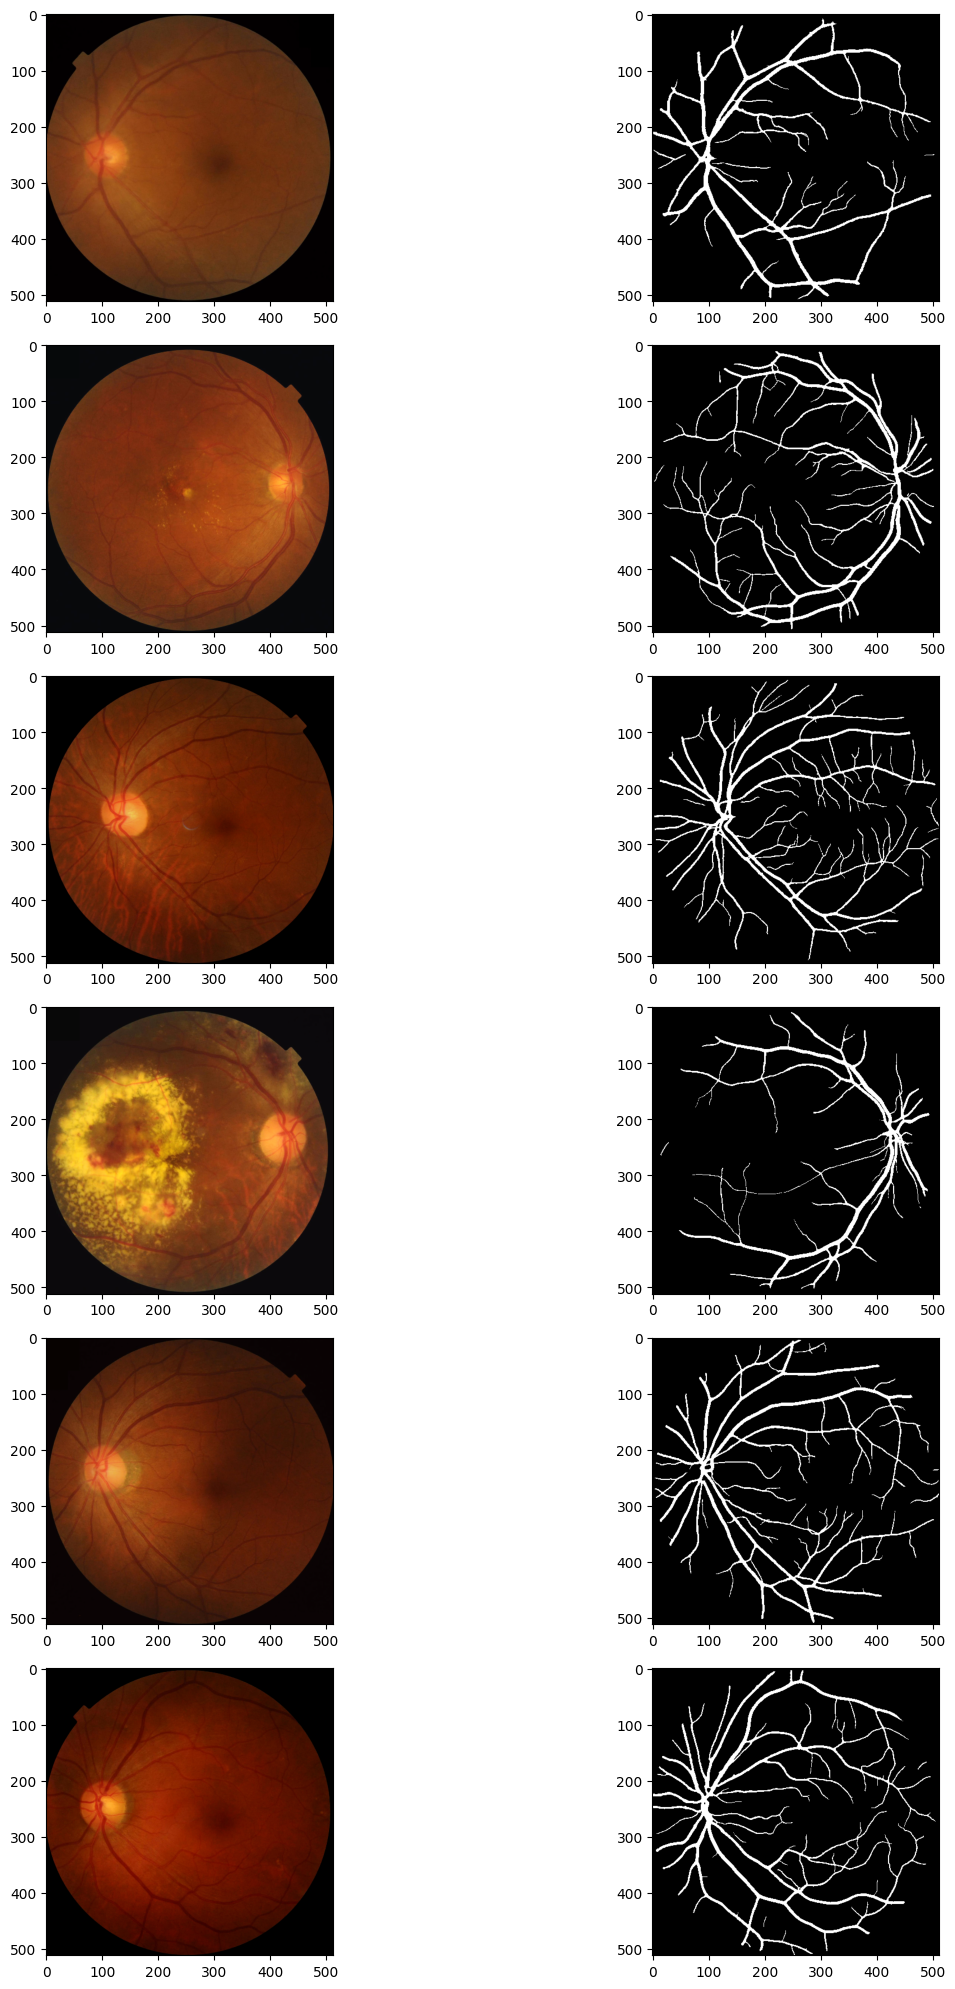

In [133]:
# Prendi un batch
images, masks = next(iter(train_dataset))
# Configura la visualizzazione
plt.figure(figsize=(10, 15))

# Ottieni i nomi delle classi
#class_names = list(train_generator.class_indices.keys())

# Mostra fino a 16 immagini (o quante ne hai nel batch)
num_images = min(6, len(images))
fig, axes = plt.subplots(num_images, 2, figsize=(15,20))

for i in range(num_images):
    print(np.max(masks[i]), np.max(images[i]))

    axes[i,0].imshow(images[i])
    axes[i,1].imshow(masks[i], cmap='grey')

plt.tight_layout()
plt.show()

## Model

In [ ]:
class ReconstructionCallback(tf.keras.callbacks.Callback):

    def __init__(self, val_generator, n=5):
        self.val_generator = val_generator
        self.n = n

    def on_epoch_end(self, epoch, logs=None):

        x_batch, y_batch = next(iter(self.val_generator))

        segmented = self.model.predict(x_batch[:self.n], verbose=0)

        fig, axes = plt.subplots(self.n, 3, figsize=(8, 3*self.n))

        for i in range(self.n):

            axes[i,0].imshow(x_batch[i])
            axes[i,0].set_title("Original")
            axes[i,0].axis("off")

            axes[i,1].imshow(y_batch[i])
            axes[i,1].set_title("Ground Truth")
            axes[i,1].axis("off")

            axes[i,2].imshow(segmented[i])
            axes[i,2].set_title("Segmented")
            axes[i,2].axis("off")

        plt.tight_layout()
        plt.show()
        


In [135]:
huber = tf.keras.losses.Huber()

# combined loss: huber + ssim
def combined_loss(y_true, y_pred):

    huber_loss = huber(y_true, y_pred)

    ssim_loss = 1 - tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

    return (
        0.7 * huber_loss
        + 0.3 * ssim_loss
    )

In [136]:
img_shape = img_shrinked + (3, )
img_shape

(512, 512, 3)

In [ ]:
# SE attention block
def se_block(x, ratio=16):

    filters = x.shape[-1]

    se = tf.keras.layers.GlobalAveragePooling2D()(x)

    se = tf.keras.layers.Dense(filters // ratio,
               activation='leaky_relu')(se)

    se = tf.keras.layers.Dense(filters,
               activation='sigmoid')(se)

    se = tf.keras.layers.Reshape((1,1,filters))(se)

    return tf.keras.layers.Multiply()([x, se])

def residual_block(x, filters):

    shortcut = x

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.LeakyReLU()(x)

    return x

def residual_downsample_block(x, filters):

    shortcut = tf.keras.layers.Conv2D(
        filters,
        kernel_size=1,
        strides=2,
        padding='same'
    )(x)

    shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        strides=2,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.activations.leaky_relu(x)

    return x

def decoder_residual_block(x, filters):

    shortcut = tf.keras.layers.Conv2D(
        filters,
        1,
        padding='same'
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])

    x = tf.keras.layers.LeakyReLU()(x)

    return x

def decoder_block(x, skip, filters):

    x = tf.keras.layers.Conv2DTranspose(
        filters,
        3,
        strides=2,
        padding='same'
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Concatenate()([x, skip])

    x = decoder_residual_block(x, filters)

    return x

def encoder(inputs):

    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = se_block(x)

    s1 = x
    x = residual_downsample_block(x, 64)
    x = residual_block(x, 64)
    x = se_block(x)

    s2 = x
    x = residual_downsample_block(x, 128)
    x = residual_block(x, 128)
    x = se_block(x)

    s3 = x
    x = residual_downsample_block(x, 256)
    x = residual_block(x, 256)
    x = se_block(x)

    s4 = x
    x = residual_downsample_block(x, 512)
    x = residual_block(x, 512)
    x = se_block(x)

    return x, [s1, s2, s3, s4]


def decoder(inputs, skips):
    s1, s2, s3, s4 = skips
    x = decoder_block(inputs, s4, 256)
    x = decoder_block(x, s3, 128)
    x = decoder_block(x, s2, 64)
    x = decoder_block(x, s1, 32)

    outputs = tf.keras.layers.Conv2D(
        1,
        1,
        activation='sigmoid',
        padding='same'
    )(x)
    
    return outputs

def create_model(inputs):
    z, skips = encoder(inputs)
    outputs = decoder(z, skips)

    return tf.keras.Model(inputs, outputs)

model = create_model( tf.keras.Input(shape=img_shape) )

In [138]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, weight_decay=1e-4),
    loss= combined_loss,
    metrics=[
        tf.keras.metrics.BinaryCrossentropy(),
        'mae',
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 512, 512,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 512, 512,  │      9,248 │ leaky_re_lu_29[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_30      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 512, 512,  │      9,248 │ leaky_re_lu_30[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ leaky_re_lu_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_31      │ (None, 512, 512,  │          0 │ add_14[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 512, 512,  │      9,248 │ leaky_re_lu_31[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_32      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 512, 512,  │      9,248 │ leaky_re_lu_32[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 512, 512,  │          0 │ batch_normalizat

 Total params: 15,346,943 (58.54 MB)

 Trainable params: 15,334,143 (58.50 MB)

 Non-trainable params: 12,800 (50.00 KB)

Callbacks

In [ ]:
# Early stopping on validation loss
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10,  
    mode='min', 
    restore_best_weights=True,
    start_from_epoch=10
)

# Scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    patience=8,
    factor=0.5,
    min_lr=1e-7
)

# Reconstruction
reconstruction_callback = ReconstructionCallback(
    val_dataset
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr, reconstruction_callback],
)

Epoch 1/3


## Analysis

In [ ]:
plt.figure(figsize = (10,7))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='validation loss') 

plt.legend()  
#plt.xticks(range(0,n_epochs))
#plt.semilogy()
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.title(f'Batch size: {batch_size}')
plt.grid('both', linestyle='--')
plt.tight_layout()
plt.savefig(f'loss_autoencoder.pdf')

KeyError: 'loss'

<Figure size 1000x700 with 0 Axes>

## Saving model

In [ ]:
model.save('brontes_seg.keras')
print('Model saved!')

## Testing on this model

Dovremmo diffidare di modelli che riproducono alla perfezione il trainset/valset perché potrebbero avere semplicemente imparato un buon modo di comprimere il set senza avere imparato davvero l'informazione. -> compressione molto efficiente del dataset.

In [142]:
test_df = create_dataframe(test_dir)


# Validation dataset without augmentation
test_images = test_df["filepath"].values
test_masks  = test_df["maskpath"].values

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_images, test_masks)
)

test_dataset = test_dataset.map(load_image_mask)
test_dataset = test_dataset.map(add_black_box)
test_dataset = test_dataset.batch(batch_size)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

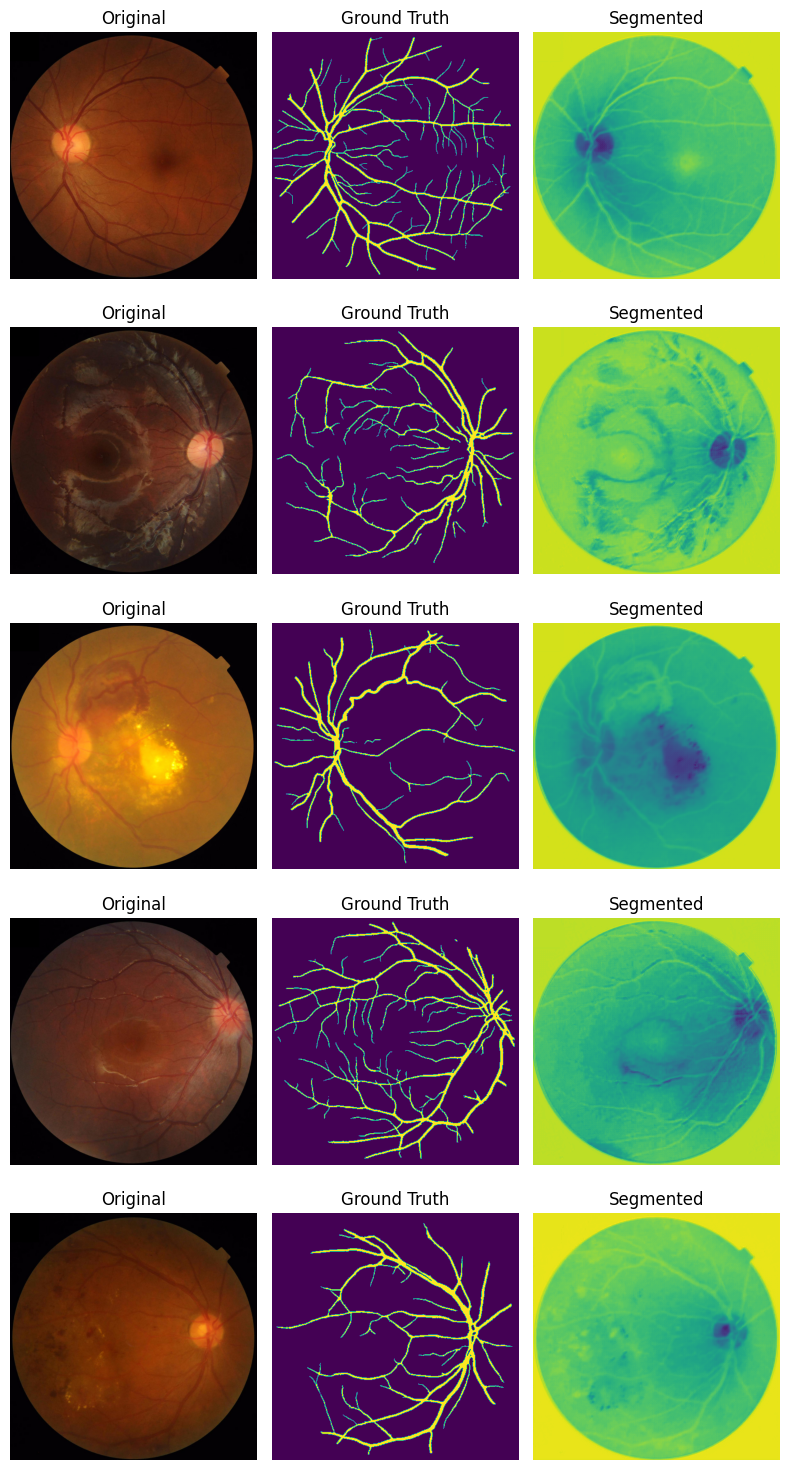

In [149]:
x_batch_test, y_batch_test = next(iter(test_dataset))

n_imgs = 5
segmented = model.predict(x_batch_test[:n_imgs], verbose=0)

fig, axes = plt.subplots(n_imgs, 3, figsize=(8, 3*n_imgs))

for i in range(n_imgs):

    axes[i,0].imshow(x_batch_test[i])
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(y_batch_test[i])
    axes[i,1].set_title("Ground Truth")
    axes[i,1].axis("off")

    axes[i,2].imshow(segmented[i])
    axes[i,2].set_title("Segmented")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()